In [2]:
import stim

from spiderstate.cat_at_origin import *
from spidercat.draw import draw_forest_on_graph
from spiderstate.utils import load_qecc
from spiderstate.stim_utils import make_stim_circ_noisy
from spidercat.simulate import _layer_cnot_circuit
from spiderstate.cat_at_origin import row_optimized_cat_at_origin
from spiderstate.utils import load_qecc, MQT_simp_QECCS
from spiderstate.qubit_reuse import build_circuit_dag, inject_qubit_reuse, apply_logical_qubit_merge_and_compress, dag_to_circuit, dag_to_noisy_circuit, VolumeOptimizingReuseStrategy

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[[0 0 1 0 1 0 0 1 1]
 [0 0 1 0 0 1 0 0 0]
 [0 0 0 1 0 0 1 0 0]
 [1 1 0 0 1 0 1 0 0]]

[[1 0 0 0 1 0 0 0 1]]

[[0 0 1 0 1 0 1 0 0]]
RX 0
R 1 2
RX 3
R 4
RX 5
R 6
RX 7
R 8 9
CX 0 9
R 10
CX 7 10 0 1 5 2 3 6 7 8 10 2 9 6 10 4 7 10
M 10
CX 9 4 0 9
M 9
DETECTOR rec[-2]
DETECTOR rec[-1]


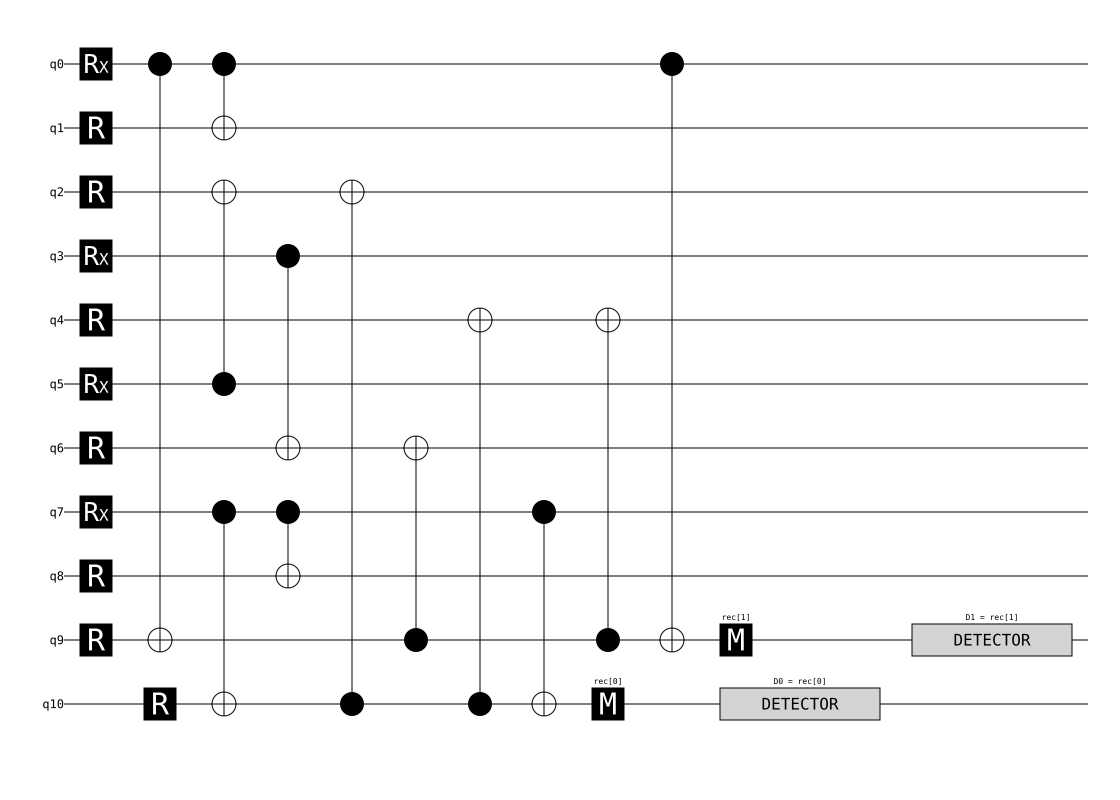

In [38]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("9_1_3", "FAO")
t = d // 2

row_M, final_M, col_ops = optimize_fault_tolerant_matrix(H_z, t=t, max_col_ops=10, max_basis_tries=10_000)
print(row_M, L_x, L_z, sep="\n\n")

circ = cat_at_origin(row_M, d)
print(circ)
circ.diagram('timeline-svg')

In [39]:
N = 10

circuit = circ.copy()
circuit.append("M", range(H_x.shape[1]))
for i, H in enumerate(H_x):
    qubit_indices = np.where(H == 1)[0]
    record_targets = [stim.target_rec(i - H_x.shape[1]) for i in qubit_indices]
    circuit.append("DETECTOR", record_targets)
for i, L in enumerate(L_x):
    qubit_indices = np.where(L == 1)[0]
    record_targets = [stim.target_rec(i - H_x.shape[1]) for i in qubit_indices]
    circuit.append("OBSERVABLE_INCLUDE", record_targets, i)
circuit.diagram('timeline-svg')
syndrome, observables = circuit.compile_detector_sampler().sample(N, separate_observables=True)

for i in range(N):
    print(f"Flags = {syndrome[i,:-H_x.shape[0]].astype(int)};\t\tSyndrome = {syndrome[i,-H_x.shape[0]:].astype(int)};\t\tLogicals = {observables[i].astype(int)}")

Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]
Flags = [0 0];		Syndrome = [0 0 0 0];		Logicals = [0]


State: |0> (Code 7_1_3)


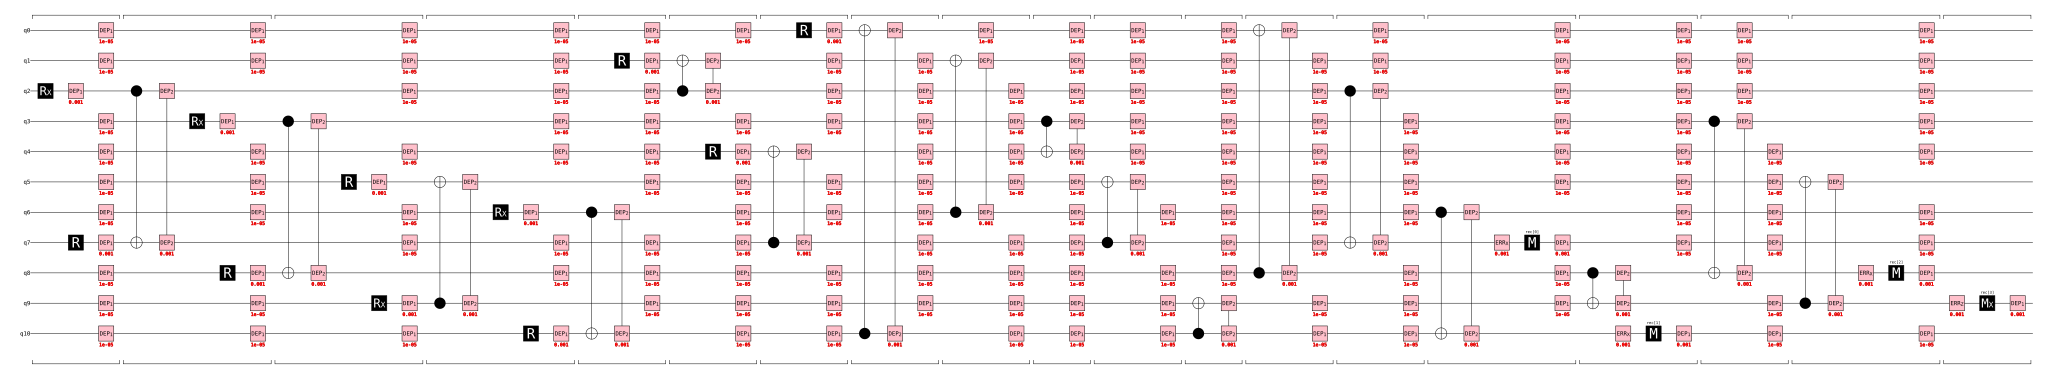

In [6]:
code = "7_1_3"
p = 0.001

is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)
if code in ("49_1_5", "95_1_7"):
    print(f"State: |+> (Code {code})")
    H_x, H_z = H_z, H_x
    L_x, L_z = L_z, L_x
else:
    print(f"State: |0> (Code {code})")

circ = row_optimized_cat_at_origin(H_z, d, max_basis_tries=25_000)


n_data = H_x.shape[1]
dag = build_circuit_dag(circ)
mod_dag, _, _ = inject_qubit_reuse(dag, n_data, VolumeOptimizingReuseStrategy())
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, n_data)
circ, _ = dag_to_circuit(compressed_dag)

noisy_circ, _ = make_stim_circ_noisy(circ, p, one_cnot_per_layer=True)
noisy_circ.diagram('timeline-svg')

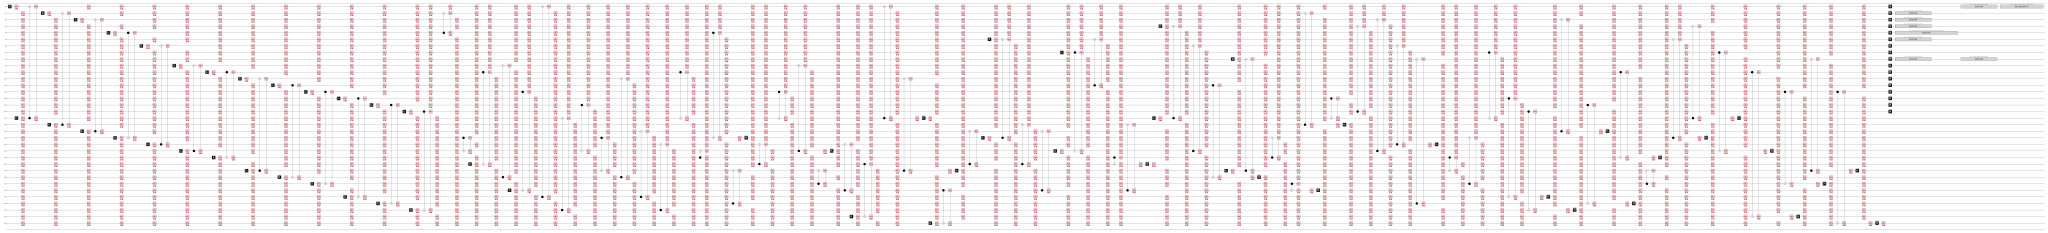

In [7]:
stim.Circuit("""
R 0
DEPOLARIZE1(0.001) 0
RX 17
DEPOLARIZE1(0.001) 17
DEPOLARIZE1(1e-05) 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 17 0
DEPOLARIZE2(0.001) 17 0
R 1
DEPOLARIZE1(0.001) 1
RX 18
DEPOLARIZE1(0.001) 18
DEPOLARIZE1(1e-05) 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 18 1
DEPOLARIZE2(0.001) 18 1
R 2
DEPOLARIZE1(0.001) 2
RX 19
DEPOLARIZE1(0.001) 19
DEPOLARIZE1(1e-05) 0 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 19 2
DEPOLARIZE2(0.001) 19 2
RX 4
DEPOLARIZE1(0.001) 4
R 20
DEPOLARIZE1(0.001) 20
DEPOLARIZE1(1e-05) 0 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 4 20
DEPOLARIZE2(0.001) 4 20
R 6
DEPOLARIZE1(0.001) 6
RX 21
DEPOLARIZE1(0.001) 21
DEPOLARIZE1(1e-05) 0 1 2 3 5 7 8 9 10 11 12 13 14 15 16 17 18 19 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 21 6
DEPOLARIZE2(0.001) 21 6
R 9
DEPOLARIZE1(0.001) 9
RX 22
DEPOLARIZE1(0.001) 22
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 7 8 10 11 12 13 14 15 16 17 18 19 20 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 22 9
DEPOLARIZE2(0.001) 22 9
RX 10
DEPOLARIZE1(0.001) 10
R 23
DEPOLARIZE1(0.001) 23
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 11 12 13 14 15 16 17 18 19 20 21 24 25 26 27 28 29 30 31 32 33
TICK
CX 10 23
DEPOLARIZE2(0.001) 10 23
R 11
DEPOLARIZE1(0.001) 11
RX 25
DEPOLARIZE1(0.001) 25
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 12 13 14 15 16 17 18 19 20 21 22 24 26 27 28 29 30 31 32 33
TICK
CX 25 11
DEPOLARIZE2(0.001) 25 11
RX 12
DEPOLARIZE1(0.001) 12
R 26
DEPOLARIZE1(0.001) 26
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 13 14 15 16 17 18 19 20 21 22 23 24 27 28 29 30 31 32 33
TICK
CX 12 26
DEPOLARIZE2(0.001) 12 26
RX 13
DEPOLARIZE1(0.001) 13
R 27
DEPOLARIZE1(0.001) 27
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 14 15 16 17 18 19 20 21 22 23 24 25 28 29 30 31 32 33
TICK
CX 13 27
DEPOLARIZE2(0.001) 13 27
RX 14
DEPOLARIZE1(0.001) 14
R 29
DEPOLARIZE1(0.001) 29
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 15 16 17 18 19 20 21 22 23 24 25 26 28 30 31 32 33
TICK
CX 14 29
DEPOLARIZE2(0.001) 14 29
RX 15
DEPOLARIZE1(0.001) 15
R 30
DEPOLARIZE1(0.001) 30
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 16 17 18 19 20 21 22 23 24 25 26 27 28 31 32 33
TICK
CX 15 30
DEPOLARIZE2(0.001) 15 30
RX 16
DEPOLARIZE1(0.001) 16
R 31
DEPOLARIZE1(0.001) 31
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 17 18 19 20 21 22 23 24 25 26 27 28 29 32 33
TICK
CX 16 31
DEPOLARIZE2(0.001) 16 31
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 17 18 19 20 21 22 23 24 25 26 27 28 29 30 32 33
TICK
CX 4 1
DEPOLARIZE2(0.001) 4 1
DEPOLARIZE1(1e-05) 0 2 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 20 22
DEPOLARIZE2(0.001) 20 22
R 24
DEPOLARIZE1(0.001) 24
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23 25 26 27 28 29 30 31 32 33
TICK
CX 10 24
DEPOLARIZE2(0.001) 10 24
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 20 21 22 23 25 26 27 28 29 30 31 32 33
TICK
CX 26 9
DEPOLARIZE2(0.001) 26 9
R 28
DEPOLARIZE1(0.001) 28
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 27 29 30 31 32 33
TICK
CX 13 28
DEPOLARIZE2(0.001) 13 28
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25 26 27 29 30 31 32 33
TICK
CX 29 0
DEPOLARIZE2(0.001) 29 0
DEPOLARIZE1(1e-05) 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 30 31 32 33
TICK
CX 31 17
DEPOLARIZE2(0.001) 31 17
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 32 33
TICK
CX 15 22
DEPOLARIZE2(0.001) 15 22
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 16 17 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 20 25
DEPOLARIZE2(0.001) 20 25
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 26 27 28 29 30 31 32 33
TICK
CX 26 11
DEPOLARIZE2(0.001) 26 11
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25 27 28 29 30 31 32 33
TICK
CX 29 19
DEPOLARIZE2(0.001) 29 19
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25 26 27 28 30 31 32 33
TICK
CX 31 21
DEPOLARIZE2(0.001) 31 21
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25 26 27 28 29 30 32 33
TICK
CX 10 17
DEPOLARIZE2(0.001) 10 17
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 23 22
DEPOLARIZE2(0.001) 23 22
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 24 25 26 27 28 29 30 31 32 33
TICK
CX 4 20
DEPOLARIZE2(0.001) 4 20
DEPOLARIZE1(1e-05) 0 1 2 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 30 25
DEPOLARIZE2(0.001) 30 25
X_ERROR(0.001) 20
M 20
DEPOLARIZE1(0.001) 20
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 26 27 28 29 31 32 33
TICK
CX 24 21
DEPOLARIZE2(0.001) 24 21
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 22 23 25 26 27 28 29 30 31 32 33
TICK
CX 13 17
DEPOLARIZE2(0.001) 13 17
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 22 9
DEPOLARIZE2(0.001) 22 9
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 27 25
DEPOLARIZE2(0.001) 27 25
Z_ERROR(0.001) 22
MX 22
DEPOLARIZE1(0.001) 22
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 26 28 29 30 31 32 33
TICK
CX 28 21
DEPOLARIZE2(0.001) 28 21
R 32
DEPOLARIZE1(0.001) 32
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25 26 27 29 30 31 33
TICK
CX 24 32
DEPOLARIZE2(0.001) 24 32
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 25 26 27 28 29 30 31 33
TICK
CX 17 0
DEPOLARIZE2(0.001) 17 0
DEPOLARIZE1(1e-05) 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 25 11
DEPOLARIZE2(0.001) 25 11
Z_ERROR(0.001) 17
MX 17
DEPOLARIZE1(0.001) 17
R 33
DEPOLARIZE1(0.001) 33
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 12 13 14 15 16 18 19 20 21 22 23 24 26 27 28 29 30 31 32
TICK
CX 28 33
DEPOLARIZE2(0.001) 28 33
Z_ERROR(0.001) 25
MX 25
DEPOLARIZE1(0.001) 25
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27 29 30 31 32
TICK
CX 24 19
DEPOLARIZE2(0.001) 24 19
RX 20
DEPOLARIZE1(0.001) 20
R 5
DEPOLARIZE1(0.001) 5
DEPOLARIZE1(1e-05) 0 1 2 3 4 6 7 8 9 10 11 12 13 14 15 16 17 18 21 22 23 25 26 27 28 29 30 31 32 33
TICK
CX 20 5
DEPOLARIZE2(0.001) 20 5
DEPOLARIZE1(1e-05) 0 1 2 3 4 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 24 18
DEPOLARIZE2(0.001) 24 18
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 19 20 21 22 23 25 26 27 28 29 30 31 32 33
TICK
CX 28 19
DEPOLARIZE2(0.001) 28 19
R 22
DEPOLARIZE1(0.001) 22
RX 7
DEPOLARIZE1(0.001) 7
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 8 9 10 11 12 13 14 15 16 17 18 20 21 23 24 25 26 27 29 30 31 32 33
TICK
CX 7 22
DEPOLARIZE2(0.001) 7 22
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 8 9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 12 5
DEPOLARIZE2(0.001) 12 5
DEPOLARIZE1(1e-05) 0 1 2 3 4 6 7 8 9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 23 24
DEPOLARIZE2(0.001) 23 24
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 25 26 27 28 29 30 31 32 33
TICK
CX 28 18
DEPOLARIZE2(0.001) 28 18
X_ERROR(0.001) 24
M 24
DEPOLARIZE1(0.001) 24
RX 17
DEPOLARIZE1(0.001) 17
R 3
DEPOLARIZE1(0.001) 3
DEPOLARIZE1(1e-05) 0 1 2 4 5 6 7 8 9 10 11 12 13 14 15 16 19 20 21 22 23 25 26 27 29 30 31 32 33
TICK
CX 17 3
DEPOLARIZE2(0.001) 17 3
DEPOLARIZE1(1e-05) 0 1 2 4 5 6 7 8 9 10 11 12 13 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 22 6
DEPOLARIZE2(0.001) 22 6
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 12 26
DEPOLARIZE2(0.001) 12 26
RX 25
DEPOLARIZE1(0.001) 25
R 8
DEPOLARIZE1(0.001) 8
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 27 28 29 30 31 32 33
TICK
CX 25 8
DEPOLARIZE2(0.001) 25 8
X_ERROR(0.001) 26
M 26
DEPOLARIZE1(0.001) 26
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 27 28 29 30 31 32 33
TICK
CX 23 20
DEPOLARIZE2(0.001) 23 20
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 24 25 26 27 28 29 30 31 32 33
TICK
CX 27 28
DEPOLARIZE2(0.001) 27 28
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 29 30 31 32 33
TICK
CX 18 1
DEPOLARIZE2(0.001) 18 1
X_ERROR(0.001) 28
M 28
DEPOLARIZE1(0.001) 28
DEPOLARIZE1(1e-05) 0 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25 26 27 29 30 31 32 33
TICK
CX 14 17
DEPOLARIZE2(0.001) 14 17
Z_ERROR(0.001) 18
MX 18
DEPOLARIZE1(0.001) 18
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 15 16 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 16 3
DEPOLARIZE2(0.001) 16 3
DEPOLARIZE1(1e-05) 0 1 2 4 5 6 7 8 9 10 11 12 13 14 15 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 22 2
DEPOLARIZE2(0.001) 22 2
DEPOLARIZE1(1e-05) 0 1 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 21 6
DEPOLARIZE2(0.001) 21 6
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 7 8 9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 30 8
DEPOLARIZE2(0.001) 30 8
Z_ERROR(0.001) 21
MX 21
DEPOLARIZE1(0.001) 21
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25 26 27 28 29 31 32 33
TICK
CX 23 25
DEPOLARIZE2(0.001) 23 25
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 24 26 27 28 29 30 31 32 33
TICK
CX 27 20
DEPOLARIZE2(0.001) 27 20
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26 28 29 30 31 32 33
TICK
CX 7 17
DEPOLARIZE2(0.001) 7 17
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 8 9 10 11 12 13 14 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 14 29
DEPOLARIZE2(0.001) 14 29
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27 28 30 31 32 33
TICK
CX 16 31
DEPOLARIZE2(0.001) 16 31
X_ERROR(0.001) 29
M 29
DEPOLARIZE1(0.001) 29
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 17 18 19 20 21 22 23 24 25 26 27 28 30 32 33
TICK
CX 19 2
DEPOLARIZE2(0.001) 19 2
X_ERROR(0.001) 31
M 31
DEPOLARIZE1(0.001) 31
DEPOLARIZE1(1e-05) 0 1 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25 26 27 28 29 30 32 33
TICK
CX 15 30
DEPOLARIZE2(0.001) 15 30
Z_ERROR(0.001) 19
MX 19
DEPOLARIZE1(0.001) 19
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 16 17 18 20 21 22 23 24 25 26 27 28 29 31 32 33
TICK
CX 10 23
DEPOLARIZE2(0.001) 10 23
X_ERROR(0.001) 30
M 30
DEPOLARIZE1(0.001) 30
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 20 21 22 24 25 26 27 28 29 31 32 33
TICK
CX 27 25
DEPOLARIZE2(0.001) 27 25
X_ERROR(0.001) 23
M 23
DEPOLARIZE1(0.001) 23
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 24 26 28 29 30 31 32 33
TICK
CX 20 5
DEPOLARIZE2(0.001) 20 5
DEPOLARIZE1(1e-05) 0 1 2 3 4 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 17 3
DEPOLARIZE2(0.001) 17 3
Z_ERROR(0.001) 20
MX 20
DEPOLARIZE1(0.001) 20
DEPOLARIZE1(1e-05) 0 1 2 4 5 6 7 8 9 10 11 12 13 14 15 16 18 19 21 22 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 7 22
DEPOLARIZE2(0.001) 7 22
Z_ERROR(0.001) 17
MX 17
DEPOLARIZE1(0.001) 17
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 8 9 10 11 12 13 14 15 16 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33
TICK
CX 10 32
DEPOLARIZE2(0.001) 10 32
X_ERROR(0.001) 22
M 22
DEPOLARIZE1(0.001) 22
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 20 21 23 24 25 26 27 28 29 30 31 33
TICK
CX 13 27
DEPOLARIZE2(0.001) 13 27
X_ERROR(0.001) 32
M 32
DEPOLARIZE1(0.001) 32
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25 26 28 29 30 31 33
TICK
CX 25 8
DEPOLARIZE2(0.001) 25 8
X_ERROR(0.001) 27
M 27
DEPOLARIZE1(0.001) 27
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 26 28 29 30 31 32 33
TICK
CX 13 33
DEPOLARIZE2(0.001) 13 33
Z_ERROR(0.001) 25
MX 25
DEPOLARIZE1(0.001) 25
DEPOLARIZE1(1e-05) 0 1 2 3 4 5 6 7 8 9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 26 27 28 29 30 31 32
TICK
X_ERROR(0.001) 33
M 33
DEPOLARIZE1(0.001) 33
TICK
M 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
DETECTOR rec[-12] rec[-8] rec[-6] rec[-5]
DETECTOR rec[-9] rec[-7] rec[-4] rec[-2]
DETECTOR rec[-14] rec[-10] rec[-3] rec[-1]
DETECTOR rec[-15] rec[-11] rec[-3] rec[-1]
DETECTOR rec[-13] rec[-12] rec[-11] rec[-10] rec[-9] rec[-7] rec[-6] rec[-1]
DETECTOR rec[-16] rec[-13] rec[-7] rec[-4]
DETECTOR rec[-9] rec[-8] rec[-6] rec[-2]
DETECTOR rec[-17] rec[-15] rec[-14] rec[-3]
OBSERVABLE_INCLUDE(0) rec[-17] rec[-16] rec[-15] rec[-13] rec[-11]
""").diagram('timeline-svg')